---
title: "Thesis figures on the fitted pipeline"
subtitle: "Reproducing two figure blocks from thesis_abcd.qmd on out/<run_id> instead of raw release files"
date: last-modified
format:
  html:
    toc: true
    toc-depth: 3
    code-fold: show
    embed-resources: true
    fig-width: 9
    fig-height: 4
execute:
  warning: false
  message: false
jupyter: abcd
---

## What this notebook reproduces, and what it deliberately drops

`thesis_abcd.qmd` (the 5.1 rough analysis, in the sibling `ABCD` repo) built
several figure blocks straight off raw release files and hand-rolled
`age9`/`age16` prediction differences. This notebook reproduces the two most
central blocks -- the mixed-effects trajectory panel, and the structural-
covariance PCA compared to AHBA C1-C3 -- on top of this repo's own fitted
pipeline (`out/<run_id>/{model_table,phenotypes,fits}`), so the figures use
the same BLUPs and reliability accounting as everything else here rather than
a second, divergent read of the raw data.

**Left out of scope on purpose**: the CBCL behavioural-association panel (it
would need a fresh loader for raw behavioural data not otherwise touched by
this pipeline) and the GPS genetic-similarity panel (it needs bivariate GCTA
GREML output; `hpc/` has the pipeline written but, per `REPORT.md`, not yet
run). Nothing below should be read as a discovery result -- see the
reliability caveat right after the data is loaded.

**Engine note.** This notebook mixes Python (data assembly, PCA) with R
(`ggseg`/`ggsegGlasser` brain maps, via `rpy2`'s `%%R` cell magic) inside a
single `jupyter: python3`-style kernel, matching `thesis_abcd.qmd`'s own
style. `tools/check_notebook_chunks.py` only handles single-engine notebooks
and cannot run `%%R` magic as a plain script, so this notebook is verified by
actually executing it (`quarto render` / Jupyter), not by that tool.

In [1]:
#| include: false
import os, sys, json
from pathlib import Path

# rpy2 embeds R via the R_HOME env var, taken literally (unlike Rscript, which
# resolves its own home and ignores a stale R_HOME). If a system R install has
# set R_HOME globally, rpy2 will try to load *that* R's libR and segfault, or
# silently miss the packages (ggseg, ggsegGlasser, pals) installed into this
# conda env's own R. Force it to this interpreter's own env before rpy2 is
# imported anywhere (the %load_ext rpy2.ipython cell below).
os.environ["R_HOME"] = str(Path(sys.prefix) / "lib" / "R")

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from abcd import genemaps as gm

pd.set_option("display.width", 100)

## Load one fitted run

In [2]:
# Either fitted run works; AHBA C1-C3 in this repo (data/ahba_dme_hcp_top8kgenes_scores.csv)
# is only wired up in HCP-MMP space (see abcd.genemaps.ahba_components), so the
# DK run falls back to the DK-space AHBA scores in the sibling AHBA repo.
RUN = "thickness_dsk_70_36738d15ec02"
# RUN = "thickness_dsk_51_32bbb98e84e4"
RUN_DIR = ROOT / "out" / RUN

manifest = json.loads((RUN_DIR / "manifest.json").read_text())
PARCELLATION = manifest["config"]["parcellation"]        # "dsk" or "hcp"
ATLAS = "dk" if PARCELLATION == "dsk" else "hcp"          # ggseg atlas name used by R/thesis_plots.R
AGE_CENTRE = manifest["age_centre"]

model_table = pd.read_parquet(RUN_DIR / "model_table.parquet",
                              columns=["subject", "label", "age", "value", "sex"])
phenotypes = pd.read_parquet(RUN_DIR / "phenotypes" / "phenotypes.parquet")
fixed = pd.read_parquet(RUN_DIR / "fits" / "fixed.parquet")

print(f"{RUN} | parcellation={PARCELLATION} atlas={ATLAS} age_centre={AGE_CENTRE:.3f}")
print(f"model_table: {model_table.shape}, phenotypes: {phenotypes.shape}")

thickness_dsk_70_36738d15ec02 | parcellation=dsk atlas=dk age_centre=12.441
model_table: (1591812, 5), phenotypes: (1671168, 13)


**Reliability caveat** (see `REPORT.md` §4): median slope reliability on
release 5.1 is ~0.12-0.16. The BLUPs used below are already shrunk toward the
group mean by that factor, which is the correct thing for a mixed model to
do, but it means the *between-subject* comparisons in this notebook (colour
in the trajectory panel, PC1 in the structural-covariance figure) are
attenuated relative to true developmental variation, and 5.1 alone cannot
distinguish that attenuation from a null result. Print the actual number
being relied on here so it isn't lost:

In [3]:
rel = (phenotypes[phenotypes.phenotype == "slope"]
      .groupby("n_visits")["reliability"].median())
print("median slope reliability by n_visits:")
print(rel)

median slope reliability by n_visits:
n_visits
2    0.129450
3    0.174607
4    0.220111
Name: reliability, dtype: float64


In [4]:
%load_ext rpy2.ipython

In [5]:
%%R
ROOT <- if (basename(getwd()) == "notebooks") ".." else "."
DATA_DIR <- file.path(ROOT, "data")
source(file.path(ROOT, "R", "thesis_plots.R"))

## Figure 1: mixed-effects trajectory panel

Four illustrative regions: the two fastest-thinning and two
slowest-thinning/thickening left-hemisphere regions by the fixed developmental
slope, so the choice is data-driven rather than hand-picked.

In [6]:
fixed_slope = (fixed[fixed.term == "age_c"]
              .set_index("label")["estimate"]
              .loc[lambda s: s.index.str.startswith("lh_")]
              .sort_values())

REGIONS_TO_PLOT = fixed_slope.index[:2].tolist() + fixed_slope.index[-2:].tolist()
print("regions (fastest thinning -> slowest thinning/thickening):", REGIONS_TO_PLOT)

regions (fastest thinning -> slowest thinning/thickening): ['lh_frontalpole', 'lh_isthmuscingulate', 'lh_temporalpole', 'lh_entorhinal']


Raw observed points, a random sample of subjects' own trajectories coloured by
their fitted slope, and the model-implied trajectory for that same sample:

In [7]:
raw_df = (model_table[model_table.label.isin(REGIONS_TO_PLOT)]
         .rename(columns={"label": "region"})
         [["subject", "region", "age", "value", "sex"]])

slope_long = (phenotypes[(phenotypes.phenotype == "slope") & phenotypes.label.isin(REGIONS_TO_PLOT)]
             [["subject", "label", "value"]]
             .rename(columns={"label": "region", "value": "slope"}))
intercept_long = (phenotypes[(phenotypes.phenotype == "intercept") & phenotypes.label.isin(REGIONS_TO_PLOT)]
                 [["subject", "label", "value"]]
                 .rename(columns={"label": "region", "value": "intercept"}))

rng = np.random.default_rng(0)
n_regions = len(REGIONS_TO_PLOT)
subjects_with_all = raw_df.groupby("subject")["region"].nunique()
eligible = subjects_with_all[subjects_with_all == n_regions].index.to_numpy()
sample_subjects = rng.choice(eligible, size=min(25, len(eligible)), replace=False)

sample_long = (raw_df[raw_df.subject.isin(sample_subjects)]
              .merge(slope_long, on=["subject", "region"], how="left"))

AGE_LO, AGE_HI = 9.0, 15.0
subj_region_re = (sample_long[["subject", "region", "slope"]].drop_duplicates()
                  .merge(intercept_long, on=["subject", "region"], how="left"))
preds_long = pd.concat([
    subj_region_re.assign(age=age, pred=lambda d, age=age: d.intercept + d.slope * (age - AGE_CENTRE))
    for age in (AGE_LO, AGE_HI)
], ignore_index=True)[["subject", "region", "age", "pred", "slope"]]

print(f"raw_df: {raw_df.shape}, sample_long: {sample_long.shape} ({len(sample_subjects)} subjects), preds_long: {preds_long.shape}")

raw_df: (93636, 5), sample_long: (276, 6) (25 subjects), preds_long: (200, 5)


A small brain map marking where the four regions sit:

In [8]:
all_lh = sorted(l for l in model_table.label.unique() if l.startswith("lh_"))
highlight_map = pd.DataFrame({"label": all_lh})
highlight_map["Selected regions"] = highlight_map.label.isin(REGIONS_TO_PLOT).astype(float)

`geom_smooth()` using formula = 'y ~ x'


merging atlas and data by 'label'
In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggseg package.
  Please report the issue at <https://github.com/ggseg/ggseg/issues>.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


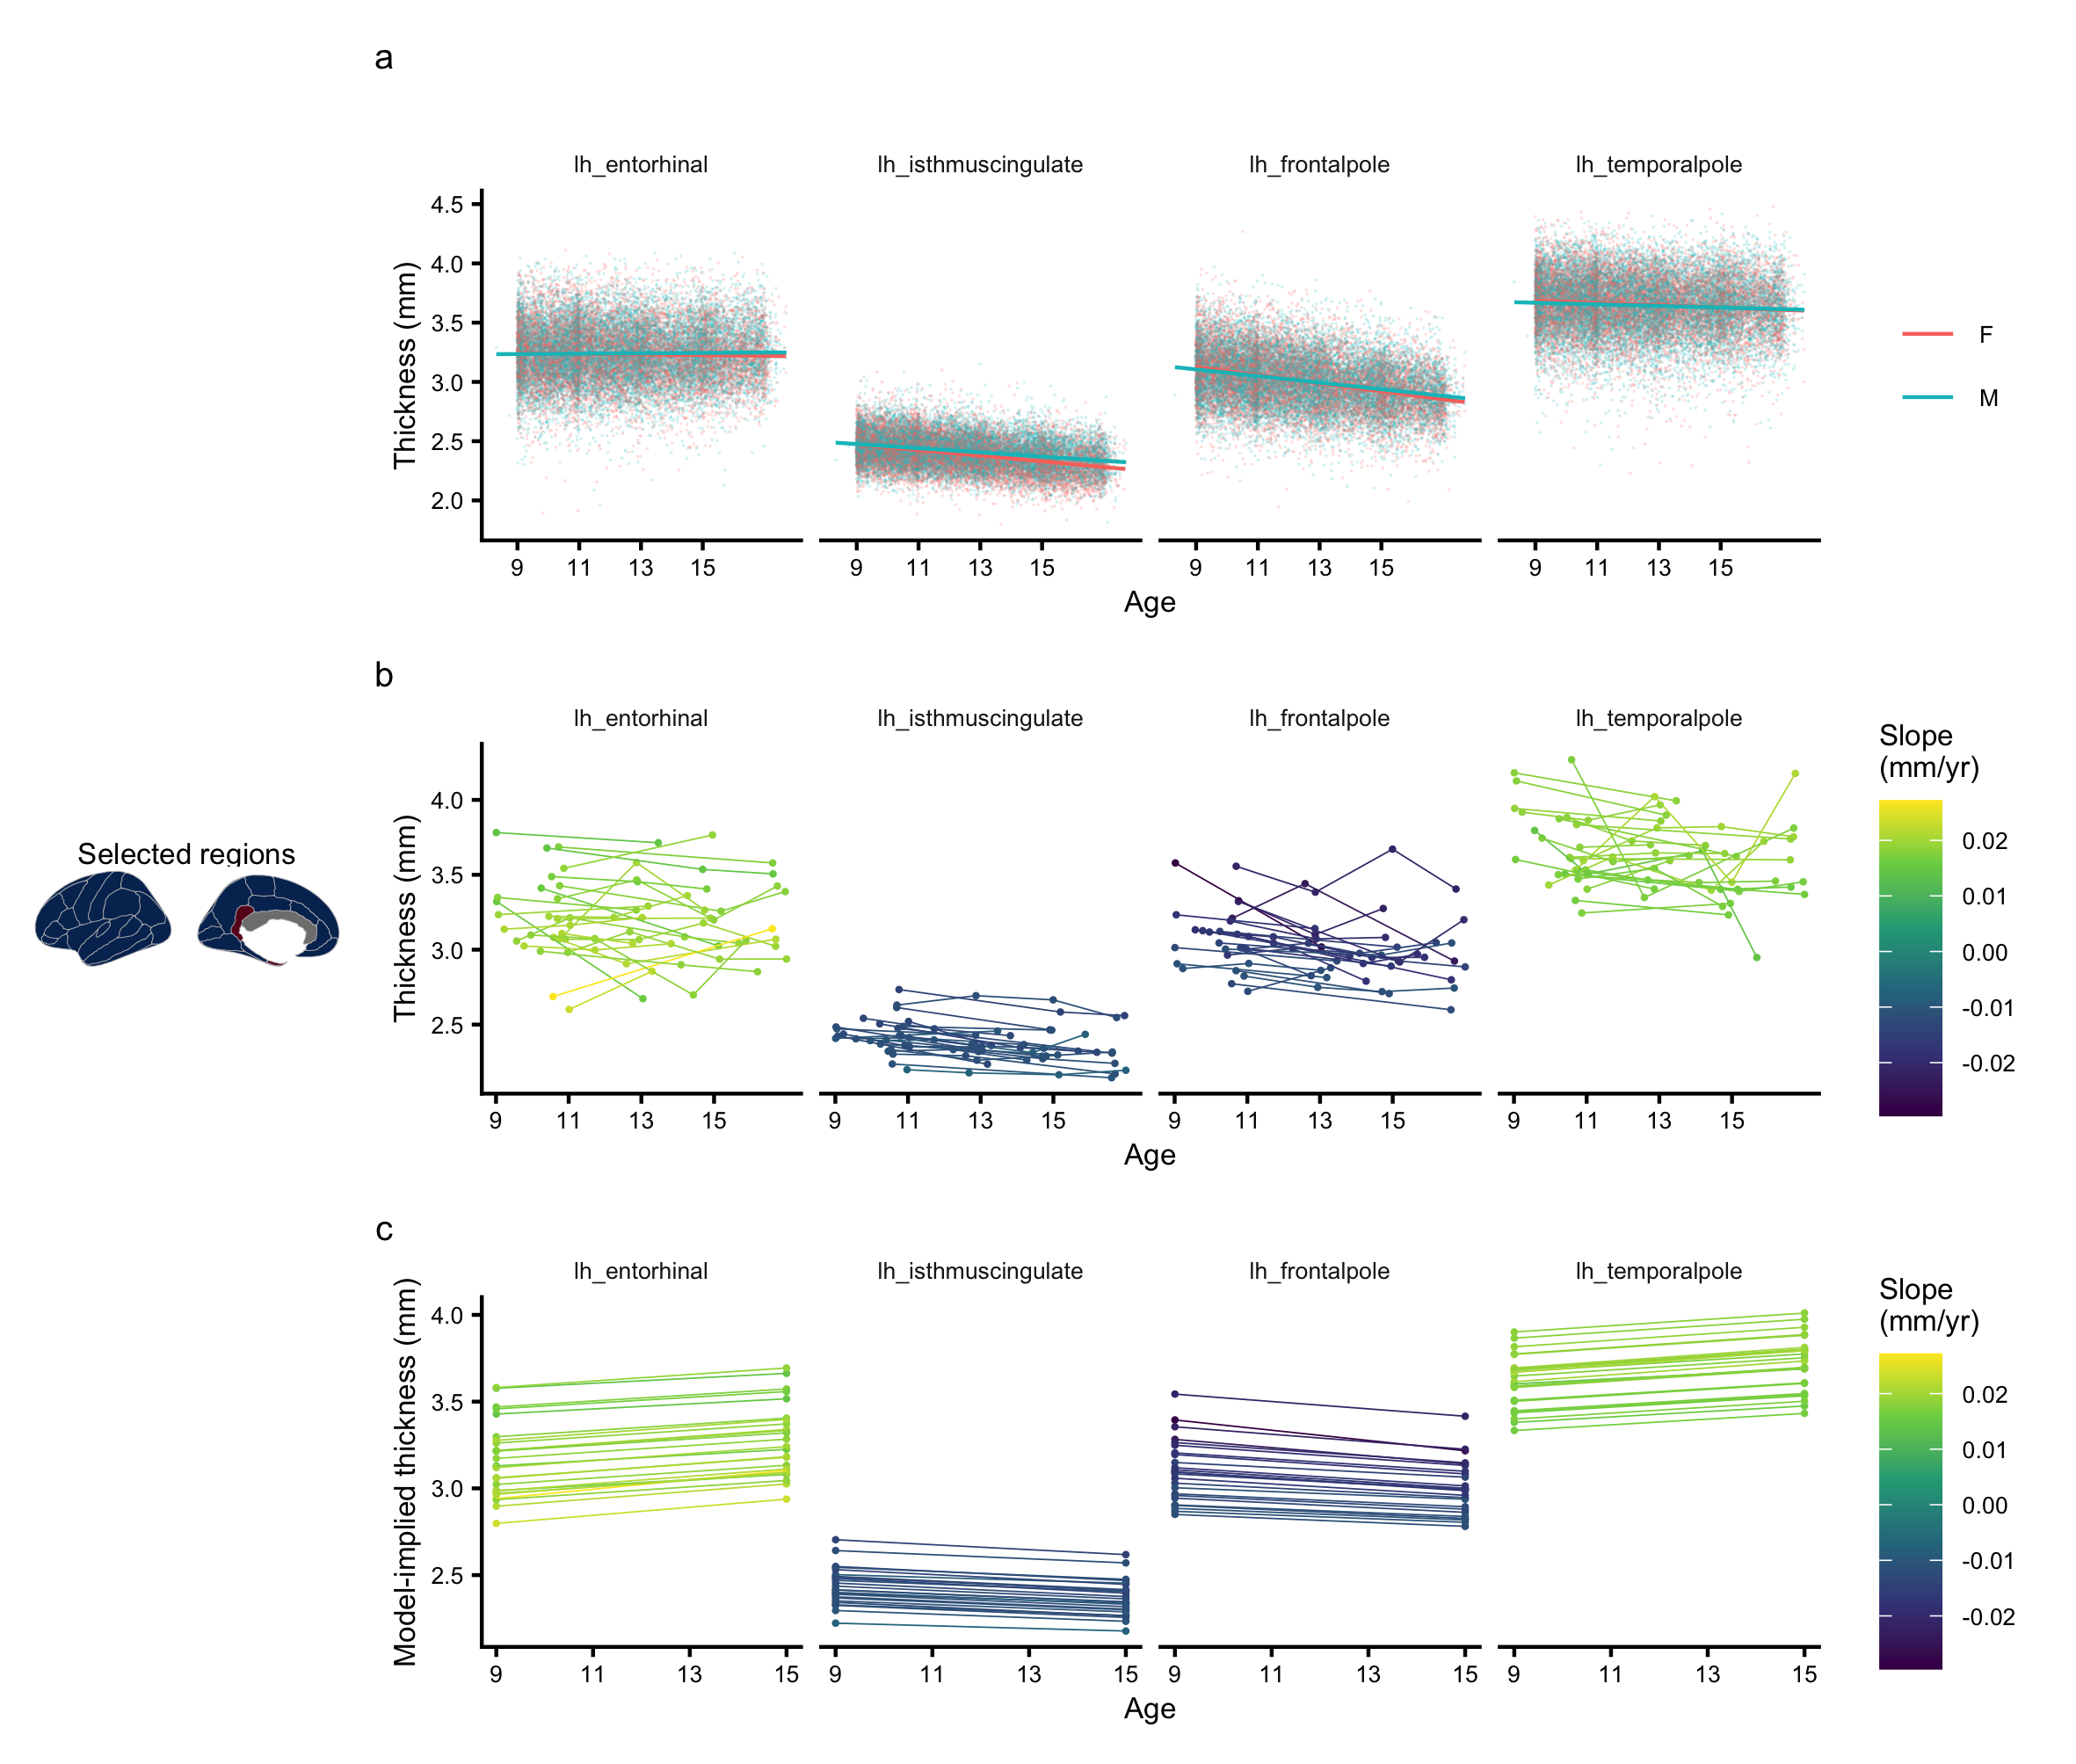

In [9]:
%%R -i raw_df -i sample_long -i preds_long -i highlight_map -i ATLAS -w 200 -h 170 -u mm -r 300
regions_order <- unique(raw_df$region)

p_highlight <- plot_map(highlight_map, atlas = ATLAS, colorscale = "fixed", limits = c(0, 1),
                        labels = c("", ""), name = "") + guides(fill = "none", color = "none")
p_points <- plot_raw_points(raw_df, regions_order) + labs(tag = "a")
p_sample <- plot_subject_sample(sample_long, regions_order) + labs(tag = "b")
p_preds <- plot_subject_preds(preds_long, regions_order) + labs(tag = "c")

layout <- c(
  area(t = 1, b = 3, l = 1, r = 2),
  area(t = 1, b = 1, l = 3, r = 10),
  area(t = 2, b = 2, l = 3, r = 10),
  area(t = 3, b = 3, l = 3, r = 10)
)
# tags are set manually above (not via plot_annotation(tag_levels=)) so the
# brain-map locator panel -- which always blanks its own tag in plot_map() --
# doesn't consume a letter that would otherwise leave the visible panels
# starting at "b"
p_highlight + p_points + p_sample + p_preds + plot_layout(design = layout)

## Figure 2: structural covariance of the slope, compared to AHBA C1-C3

Region-region Pearson correlation of the subject-level slope deviations
(`phenotype == "slope_dev"`, left hemisphere only, mirroring the bilateral
symmetry assumption `thesis_abcd.qmd` also made), PCA'd, and compared to the
AHBA differential-expression components.

**This is a plain Pearson correlation with no spin test** -- it is a
visual reproduction of the original figure, not a new inference; see
`notebooks/02_maps_and_genes.qmd` for the calibrated spatial-null version of
a map-to-map comparison.

In [11]:
slope_dev = phenotypes[phenotypes.phenotype == "slope_dev"]
wide = (slope_dev[slope_dev.label.str.startswith("lh_")]
       .pivot(index="subject", columns="label", values="value"))
print(f"{wide.shape[1]} left-hemisphere regions x {wide.shape[0]} subjects")

corr = wide.corr()

pca = PCA(n_components=3).fit(corr.fillna(1).to_numpy())
var_exp = [f"ABCD PC{i + 1} ({v:.0%})" for i, v in enumerate(pca.explained_variance_ratio_)]
pcs = pd.DataFrame(pca.transform(corr.fillna(1).to_numpy()), index=corr.columns, columns=var_exp)
pcs = pcs.apply(lambda col: col / col.std())
pcs.index.name = "label"
print(var_exp)

region_order = pcs.iloc[:, 0].sort_values().index.tolist()

R_long = corr.copy()
R_long.index.name, R_long.columns.name = "x", "y"
R_long = R_long.stack().rename("r").reset_index().query("x != y")

34 left-hemisphere regions x 8192 subjects
['ABCD PC1 (20%)', 'ABCD PC2 (13%)', 'ABCD PC3 (9%)']


In [15]:
def load_ahba_scores(parcellation):
    """AHBA C1-C3, indexed by bare (no lh_/rh_) region name."""
    if parcellation == "hcp":
        return gm.ahba_components("hcp")[["C1", "C2", "C3"]]
    # path = ROOT.parent / "AHBA" / "outputs" / "ahba_dme_scores_in_dk.csv"
    path = ROOT / "data" / "ahba_dme_dsk_scores.csv"
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.str.replace("^lh_", "", regex=True)
    return df[["C1", "C2", "C3"]]

ahba = load_ahba_scores(PARCELLATION)

pcs_bare = pcs.copy()
pcs_bare.index = pcs_bare.index.str.replace("^(lh_|rh_)", "", regex=True)
common = pcs_bare.index.intersection(ahba.index)
print(f"{len(common)} of {len(pcs_bare)} regions have AHBA coverage")

pcs_long = pcs_bare.loc[common].reset_index(names="bare").melt(id_vars="bare", var_name="ABCD", value_name="ABCD_score")
ahba_long = ahba.loc[common].reset_index(names="bare").melt(id_vars="bare", var_name="AHBA", value_name="AHBA_score")
compare_long = pcs_long.merge(ahba_long, on="bare", how="inner")

pcs_for_map = pcs.reset_index()
ahba_for_map = ahba.loc[common].copy()
ahba_for_map.index = "lh_" + ahba_for_map.index
ahba_for_map.index.name = "label"
ahba_for_map = ahba_for_map.reset_index()

34 of 34 regions have AHBA coverage


`geom_smooth()` using formula = 'y ~ x'


merging atlas and data by 'label'
merging atlas and data by 'label'


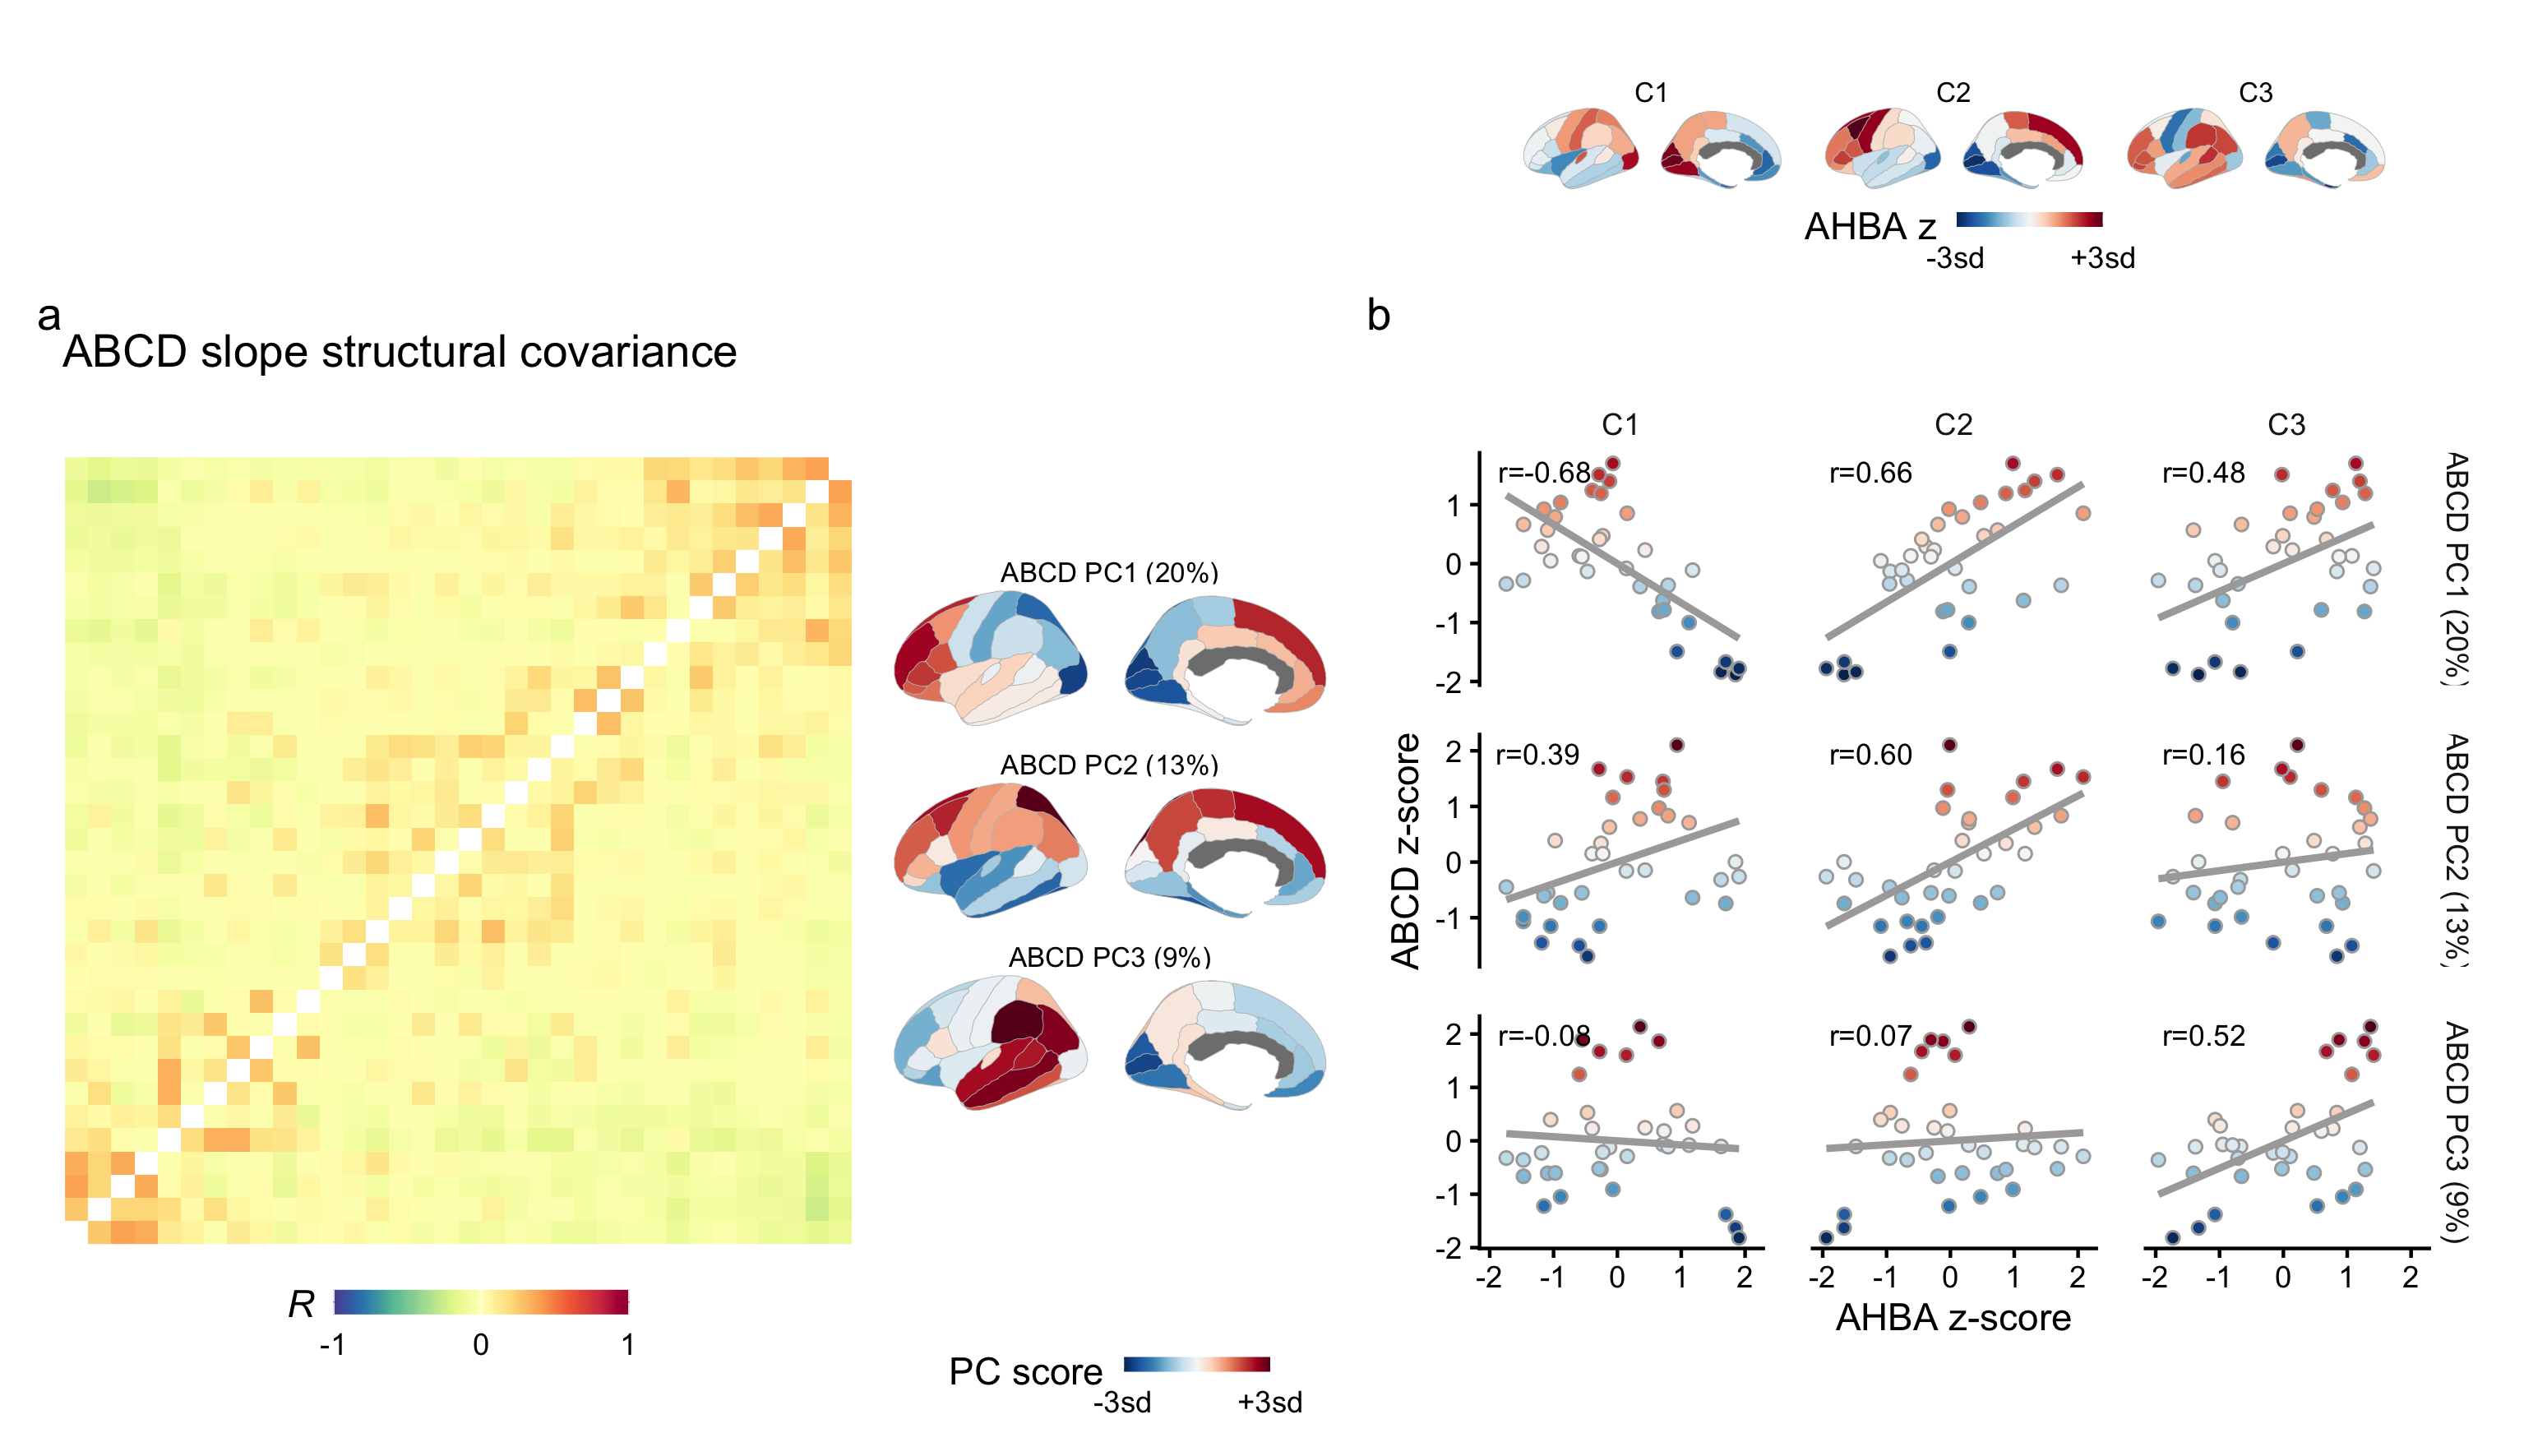

In [16]:
%%R -i R_long -i region_order -i pcs_for_map -i ahba_for_map -i compare_long -i ATLAS -w 260 -h 150 -u mm -r 300
p_R <- plot_corr_matrix(R_long, region_order, name = "ABCD slope structural covariance") + labs(tag = "a")
p_pcs <- plot_map(pcs_for_map, atlas = ATLAS, ncol = 1, colorscale = "symmetric",
                  labels = c("-3sd", "+3sd"), name = "PC score")
p_ahba <- plot_map(ahba_for_map, atlas = ATLAS, ncol = 3, colorscale = "symmetric",
                   labels = c("-3sd", "+3sd"), name = "AHBA z")
p_scatter <- plot_ahba_scatter(compare_long) + labs(tag = "b")

layout <- c(
  area(t = 2, b = 10, l = 1, r = 5),
  area(t = 2, b = 10, l = 6, r = 8),
  area(t = 1, b = 1, l = 9, r = 14),
  area(t = 2, b = 10, l = 9, r = 14)
)
# tags are set manually above; the brain-map panels (p_pcs, p_ahba) always
# blank their own tag in plot_map()
p_R + p_pcs + p_ahba + p_scatter + plot_layout(design = layout)